<a href="https://colab.research.google.com/github/sumedh019/Cardio-Risk-Analysis/blob/main/Cardio_vascular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("=" * 60)
print("STEP 1 — LOAD DATA")
print("=" * 60)

df_raw = pd.read_csv("LASI_cleaned.csv")
print(f"Raw shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(df_raw.head(3))

STEP 1 — LOAD DATA
Raw shape: 73,408 rows × 29 columns
        Patient_ID  Age  Gender  Female  Urban_Rural  State  Education_Level  \
0  101000100040101   70       1       0            1      1                0   
1  101000100040102   68       2       1            1      1                0   
2  101000100130101   54       1       0            1      1                5   

   Education_Years        BMI BMI_Category  ...  Heart_Attack_Ever  \
0                0  16.406250  Underweight  ...                0.0   
1                0  26.314636   Overweight  ...                0.0   
2               12  23.335466   Overweight  ...                0.0   

   Health_Insurance_Gov  Living_Arrangement  Lives_Alone  Annual_Income  \
0                   0.0                 2.0            0        24750.0   
1                   0.0                 2.0            0        24750.0   
2                   0.0                 4.0            0        87560.0   

   Wealth_Total  Wealth_Quintile  Stress_S

In [ ]:
print("\n" + "=" * 60)
print("STEP 2 — DATA CLEANING")
print("=" * 60)

df = df_raw.copy()


STEP 2 — DATA CLEANING


In [ ]:
df.drop(columns=['Patient_ID'], inplace=True)

In [ ]:
TARGET_COL = "Heart_Attack_Ever"
before = len(df)
df.dropna(subset=[TARGET_COL], inplace=True)
print(f"[Target NaN drop] Removed {before - len(df):,} rows → {len(df):,} rows remain")

[Target NaN drop] Removed 197 rows → 73,211 rows remain


In [ ]:
bmi_order = {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3}
df['BMI_Category_Enc'] = df['BMI_Category'].map(bmi_order)
df.drop(columns=['BMI_Category'], inplace=True)

In [ ]:
CLINICAL_FEATS = [
    'Age', 'BMI', 'Systolic_BP', 'Diastolic_BP',
    'Hypertension_Active', 'Diabetes_Active', 'Heart_Attack_2yr'
]
LIFESTYLE_FEATS = [
    'Smoking_Current', 'Alcohol_Last3M',
    'Physical_Activity_Score', 'Physical_Activity_Active',
    'BMI_Category_Enc'
]
SOCIOECONOMIC_FEATS = [
    'Education_Level', 'Education_Years', 'Annual_Income',
    'Wealth_Total', 'Wealth_Quintile', 'Health_Insurance_Gov',
    'Living_Arrangement', 'Lives_Alone', 'Urban_Rural'
]
PSYCH_FEATS = [
    'Stress_Score_CES_D', 'Stress_Score_CES_D_L', 'Depression_Present'
]
DEMO_FEATS = ['Gender', 'Female', 'State']

ALL_FEATURES = CLINICAL_FEATS + LIFESTYLE_FEATS + SOCIOECONOMIC_FEATS + PSYCH_FEATS + DEMO_FEATS

In [ ]:
missing = df[ALL_FEATURES].isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("\nMissing values BEFORE imputation:")
print(missing_df)


Missing values BEFORE imputation:
                         Missing Count  Missing %
BMI                               7124       9.73
BMI_Category_Enc                  7124       9.73
Diastolic_BP                      6545       8.94
Systolic_BP                       6545       8.94
Depression_Present                1711       2.34
Stress_Score_CES_D                1711       2.34
Stress_Score_CES_D_L              1711       2.34
Living_Arrangement                 745       1.02
Health_Insurance_Gov               642       0.88
Physical_Activity_Score            483       0.66
Smoking_Current                    473       0.65
Alcohol_Last3M                     461       0.63
Heart_Attack_2yr                   388       0.53
Annual_Income                      199       0.27
Wealth_Quintile                     36       0.05
Wealth_Total                        36       0.05


In [ ]:
MEDIAN_IMPUTE = ['BMI', 'Systolic_BP', 'Diastolic_BP',
                 'Physical_Activity_Score', 'Annual_Income',
                 'Wealth_Total', 'Stress_Score_CES_D', 'Stress_Score_CES_D_L']
MODE_IMPUTE   = ['Smoking_Current', 'Alcohol_Last3M', 'Health_Insurance_Gov',
                 'Living_Arrangement', 'Depression_Present', 'Heart_Attack_2yr',
                 'Wealth_Quintile']
for col in MEDIAN_IMPUTE:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

for col in MODE_IMPUTE:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
if df['BMI_Category_Enc'].isnull().any():
    df['BMI_Category_Enc'] = df['BMI_Category_Enc'].fillna(df['BMI_Category_Enc'].mode()[0])

In [ ]:
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("\nMissing values AFTER imputation:")
remaining = df[ALL_FEATURES].isnull().sum().sum()
print(f"  Total remaining NaNs: {remaining}")


Missing values AFTER imputation:
  Total remaining NaNs: 0


In [ ]:
CLIP_COLS = ['BMI', 'Systolic_BP', 'Diastolic_BP', 'Physical_Activity_Score',
             'Annual_Income', 'Wealth_Total', 'Age']
print("\nOutlier clipping (IQR ×3):")
for col in CLIP_COLS:
    if col not in df.columns:
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 3 * IQR, Q3 + 3 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
    print(f"  {col}: {n_out} outliers clipped → range [{df[col].min():.1f}, {df[col].max():.1f}]")


Outlier clipping (IQR ×3):
  BMI: 88 outliers clipped → range [4.4, 42.1]
  Systolic_BP: 27 outliers clipped → range [60.0, 205.5]
  Diastolic_BP: 32 outliers clipped → range [41.0, 123.5]
  Physical_Activity_Score: 0 outliers clipped → range [3.0, 15.0]
  Annual_Income: 2378 outliers clipped → range [-546140.0, 806470.0]
  Wealth_Total: 3608 outliers clipped → range [-5919200.0, 8604400.0]
  Age: 0 outliers clipped → range [18.0, 116.0]


In [ ]:
pos = df[TARGET_COL].sum()
neg = len(df) - pos
ratio = neg / pos
print(f"\nClass balance — Positive (1): {int(pos):,}  Negative (0): {int(neg):,}  Ratio: {ratio:.1f}:1")
print("NOTE: Imbalanced dataset — LightGBM team should use class_weight / scale_pos_weight")


Class balance — Positive (1): 1,364  Negative (0): 71,847  Ratio: 52.7:1
NOTE: Imbalanced dataset — LightGBM team should use class_weight / scale_pos_weight


In [ ]:
print("\n" + "=" * 60)
print("STEP 3 — FEATURE ENGINEERING")
print("=" * 60)


STEP 3 — FEATURE ENGINEERING


In [ ]:
df['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']
print("Created: Pulse_Pressure (Systolic − Diastolic)")

Created: Pulse_Pressure (Systolic − Diastolic)


In [ ]:
df['Hypertension_Diabetes'] = (
    (df['Hypertension_Active'] == 1) & (df['Diabetes_Active'] == 1)
).astype(int)
print("Created: Hypertension_Diabetes (comorbidity flag)")

Created: Hypertension_Diabetes (comorbidity flag)


In [ ]:
df['Age_Group'] = pd.cut(df['Age'],
    bins=[0, 40, 55, 65, 80, 120],
    labels=['<40', '40–54', '55–64', '65–79', '80+'])
print("Created: Age_Group (5 buckets)")

Created: Age_Group (5 buckets)


In [ ]:
df['SES_Risk'] = (
    (df['Wealth_Quintile'] <= 2).astype(int) +
    (df['Education_Level'] <= 2).astype(int) +
    (df['Health_Insurance_Gov'] == 0).astype(int)
)
print("Created: SES_Risk (0–3 composite)")

print(f"\nFinal dataset shape: {df.shape}")

Created: SES_Risk (0–3 composite)

Final dataset shape: (73211, 33)


In [ ]:
out_path = "LASI_preprocessed.csv"
df.to_csv(out_path, index=False)
print(f"\nCleaned dataset saved → {out_path}")


Cleaned dataset saved → LASI_preprocessed.csv


In [ ]:
# EDA visualization
#helper
def save_fig(name):
    plt.savefig(f"{name}.png", dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {name}.png")


[Plot 1] Missing value heatmap


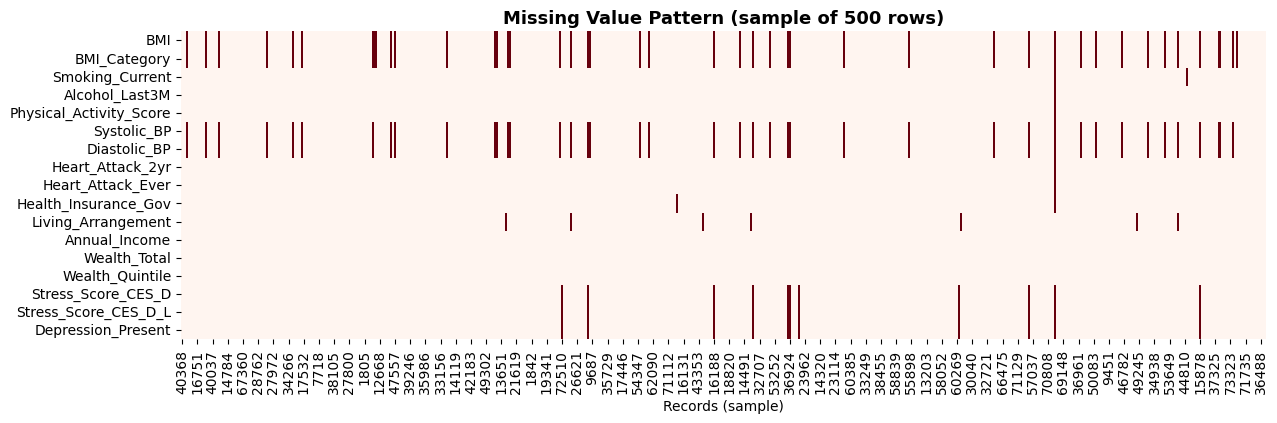

In [ ]:
# missing values
print("\n[Plot 1] Missing value heatmap")
miss_check = df_raw.drop(columns=['Patient_ID']).isnull()
miss_cols = miss_check.columns[miss_check.any()]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(miss_check[miss_cols].sample(min(500, len(df_raw)), random_state=42).T,
            cbar=False, cmap='Reds', ax=ax, yticklabels=True)
ax.set_title("Missing Value Pattern (sample of 500 rows)", fontsize=13, fontweight='bold')
ax.set_xlabel("Records (sample)")
plt.show()

[Plot 2] Target distribution


Text(0, 0.5, 'Count')

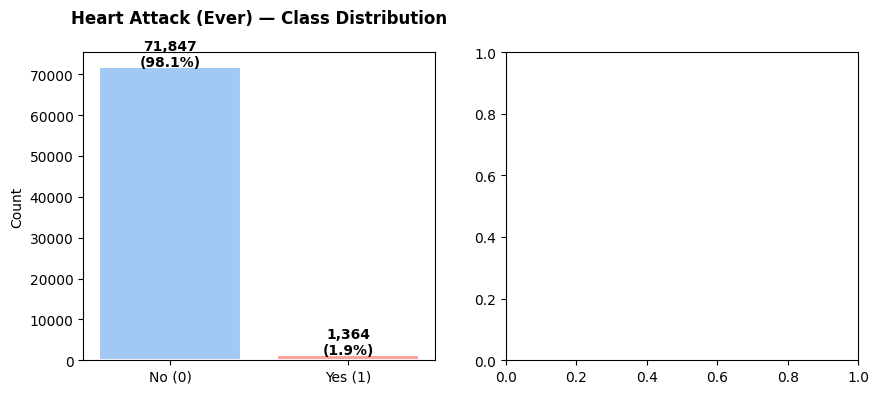

In [ ]:
print("[Plot 2] Target distribution")
PALETTE = sns.color_palette('pastel')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df[TARGET_COL].value_counts()
axes[0].bar(['No (0)', 'Yes (1)'], counts.values,
            color=[PALETTE[0], PALETTE[3]], edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title("Heart Attack (Ever) — Class Distribution\n", fontweight='bold')
axes[0].set_ylabel("Count")

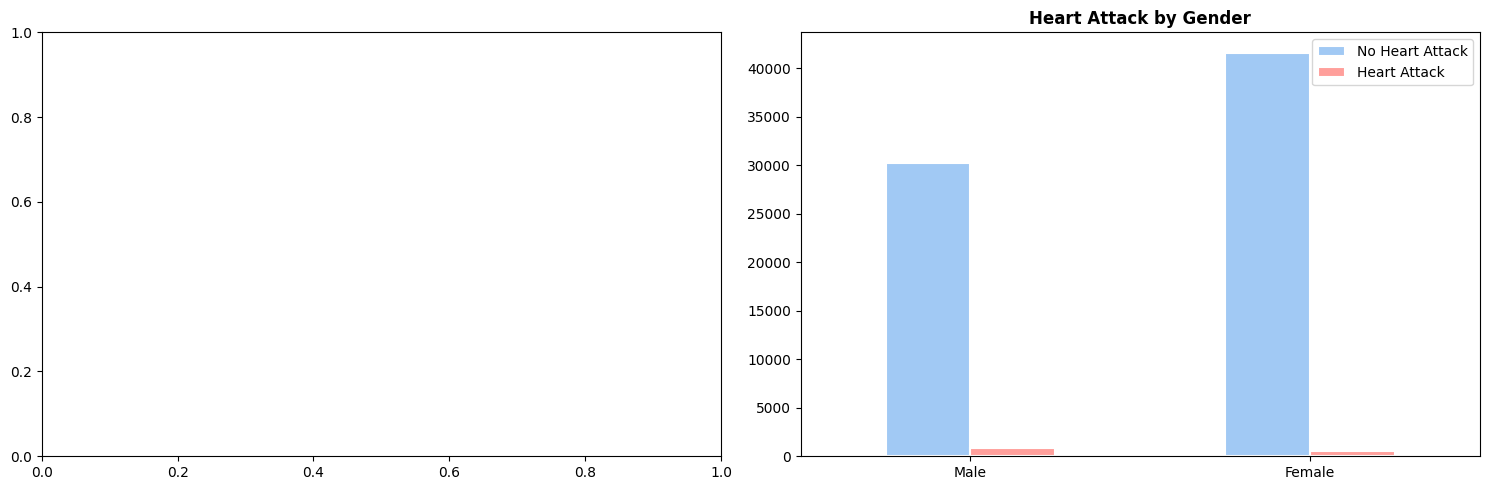

In [ ]:
# 1. Initialize the figure and axes in the SAME cell
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 2. Your data manipulation
gender_target = df.groupby(['Female', TARGET_COL]).size().unstack(fill_value=0)
gender_target.index = ['Male', 'Female']
gender_target.columns = ['No Heart Attack', 'Heart Attack']

# 3. Plot to the specific axis (axes[1])
gender_target.plot(kind='bar', ax=axes[1], color=[PALETTE[0], PALETTE[3]],
                   edgecolor='white', linewidth=1.5)

# 4. Formatting
axes[1].set_title("Heart Attack by Gender", fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_xticklabels(['Male', 'Female'], rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

[Plot 3] Clinical distributions by target


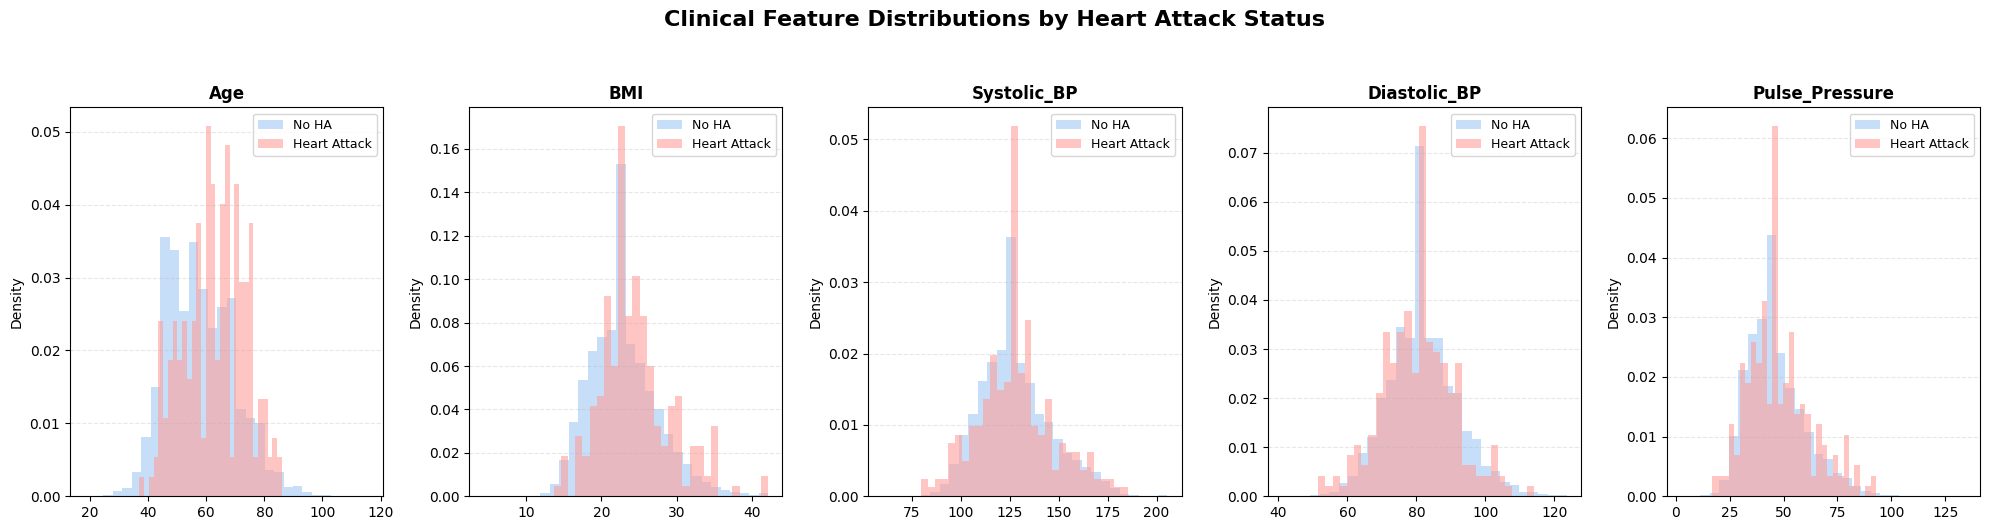

In [ ]:
# 1. Setup the data and labels
print("[Plot 3] Clinical distributions by target")
cont_clinical = ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Pulse_Pressure']
TARGET_COL = 'Heart_Attack_2yr' # Ensuring this is defined
# 2. Initialize the figure with subplots
# We create one row and as many columns as we have features
fig, axes = plt.subplots(1, len(cont_clinical), figsize=(20, 5))
# 3. Loop through each clinical feature and create the histogram
for ax, col in zip(axes, cont_clinical):
    for val, label, color in zip([0, 1], ['No HA', 'Heart Attack'], [PALETTE[0], PALETTE[3]]):
        # Create a subset for each target class
        subset = df[df[TARGET_COL] == val][col].dropna() # Dropping NaNs ensures the hist function doesn't break

        # Plotting density=True allows us to compare groups of different sizes
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
    # Formatting each individual subplot
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
# 4. Global formatting
plt.suptitle("Clinical Feature Distributions by Heart Attack Status",
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
# 5. Save and Display
# Important: plt.show() should come after save_fig if save_fig doesn't close the plot
#save_fig("plot3_clinical_distributions")
plt.show()

[Plot 4] Binary feature heart attack rates


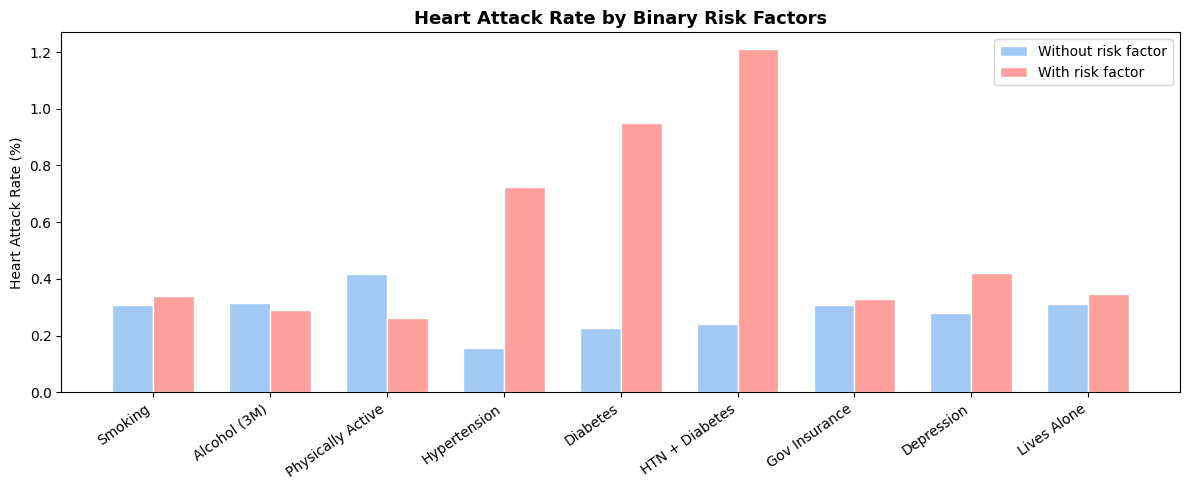

In [ ]:
print("[Plot 4] Binary feature heart attack rates")
binary_feats = [
    ('Smoking_Current', 'Smoking'),
    ('Alcohol_Last3M', 'Alcohol (3M)'),
    ('Physical_Activity_Active', 'Physically Active'),
    ('Hypertension_Active', 'Hypertension'),
    ('Diabetes_Active', 'Diabetes'),
    ('Hypertension_Diabetes', 'HTN + Diabetes'),
    ('Health_Insurance_Gov', 'Gov Insurance'),
    ('Depression_Present', 'Depression'),
    ('Lives_Alone', 'Lives Alone'),
]
rates = []
for col, label in binary_feats:
    r0 = df[df[col] == 0][TARGET_COL].mean() * 100
    r1 = df[df[col] == 1][TARGET_COL].mean() * 100
    rates.append({'Feature': label, 'Without (0)': r0, 'With (1)': r1})
rate_df = pd.DataFrame(rates).set_index('Feature')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(rate_df))
w = 0.35
ax.bar(x - w/2, rate_df['Without (0)'], width=w, color=PALETTE[0],
       label='Without risk factor', edgecolor='white')
ax.bar(x + w/2, rate_df['With (1)'], width=w, color=PALETTE[3],
       label='With risk factor', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(rate_df.index, rotation=35, ha='right')
ax.set_ylabel("Heart Attack Rate (%)")
ax.set_title("Heart Attack Rate by Binary Risk Factors", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

[Plot 5] Age group analysis


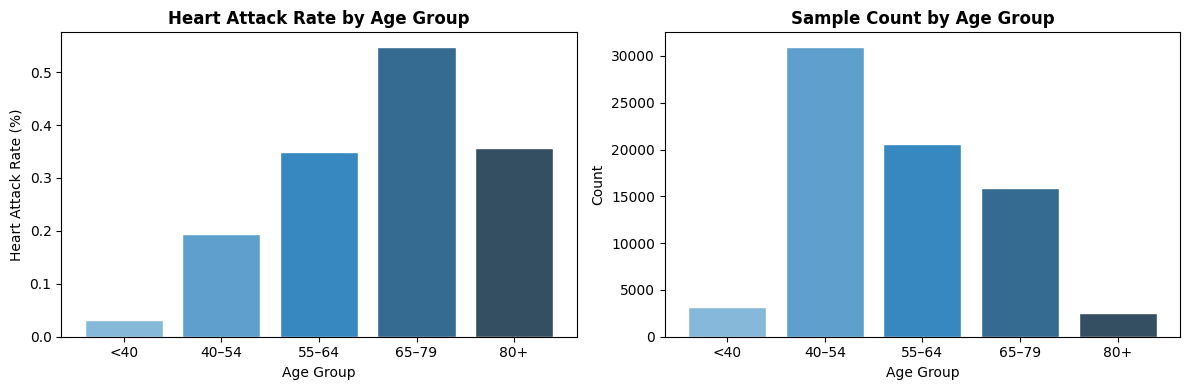

In [ ]:
print("[Plot 5] Age group analysis")
age_ha = df.groupby('Age_Group', observed=True)[TARGET_COL].agg(['mean', 'count'])
age_ha['mean'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = sns.color_palette("Blues_d", n_colors=len(age_ha))

axes[0].bar(age_ha.index.astype(str), age_ha['mean'], color=colors, edgecolor='white')
axes[0].set_title("Heart Attack Rate by Age Group", fontweight='bold')
axes[0].set_ylabel("Heart Attack Rate (%)")
axes[0].set_xlabel("Age Group")

axes[1].bar(age_ha.index.astype(str), age_ha['count'], color=colors, edgecolor='white')
axes[1].set_title("Sample Count by Age Group", fontweight='bold')
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Age Group")
plt.tight_layout()
plt.show()

[Plot 6] Wealth quintile heart attack rate


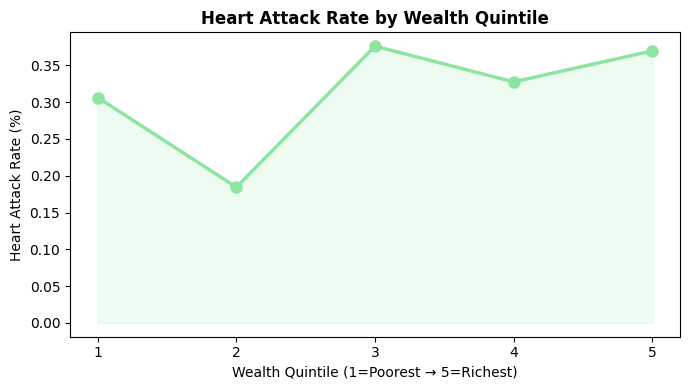

In [ ]:
print("[Plot 6] Wealth quintile heart attack rate")
wq = df.groupby('Wealth_Quintile')[TARGET_COL].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(wq.index, wq.values, marker='o', color=PALETTE[2],
        linewidth=2.5, markersize=8)
ax.fill_between(wq.index, wq.values, alpha=0.15, color=PALETTE[2])
ax.set_xlabel("Wealth Quintile (1=Poorest → 5=Richest)")
ax.set_ylabel("Heart Attack Rate (%)")
ax.set_title("Heart Attack Rate by Wealth Quintile", fontweight='bold')
ax.set_xticks(wq.index)
plt.tight_layout()

[Plot 7] Correlation heatmap


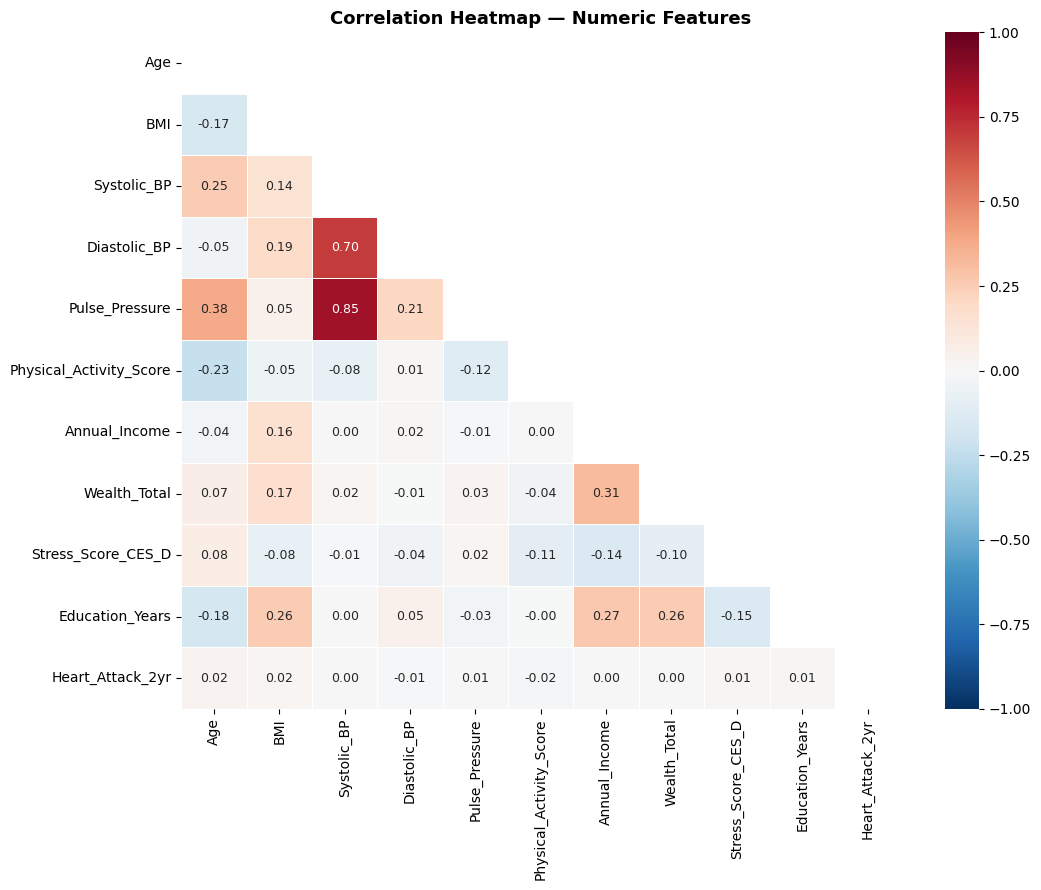

In [ ]:
print("[Plot 7] Correlation heatmap")
num_cols = ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Pulse_Pressure',
            'Physical_Activity_Score', 'Annual_Income', 'Wealth_Total',
            'Stress_Score_CES_D', 'Education_Years', TARGET_COL]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9}, vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

[Plot 8] SES Risk Score


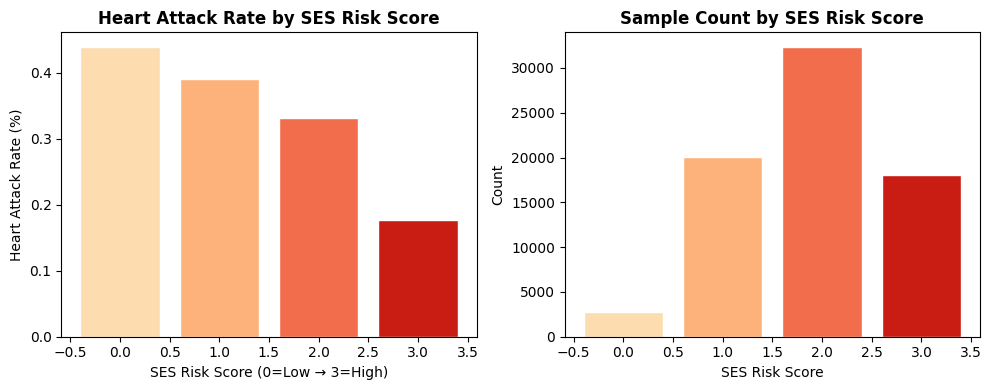

In [ ]:
print("[Plot 8] SES Risk Score")
ses = df.groupby('SES_Risk')[TARGET_COL].agg(['mean', 'count'])
ses['mean'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(ses.index, ses['mean'],
            color=sns.color_palette("OrRd", n_colors=len(ses)), edgecolor='white')
axes[0].set_xlabel("SES Risk Score (0=Low → 3=High)")
axes[0].set_ylabel("Heart Attack Rate (%)")
axes[0].set_title("Heart Attack Rate by SES Risk Score", fontweight='bold')

axes[1].bar(ses.index, ses['count'],
            color=sns.color_palette("OrRd", n_colors=len(ses)), edgecolor='white')
axes[1].set_xlabel("SES Risk Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Sample Count by SES Risk Score", fontweight='bold')
plt.tight_layout()
plt.show()

[Plot 9] Urban vs Rural


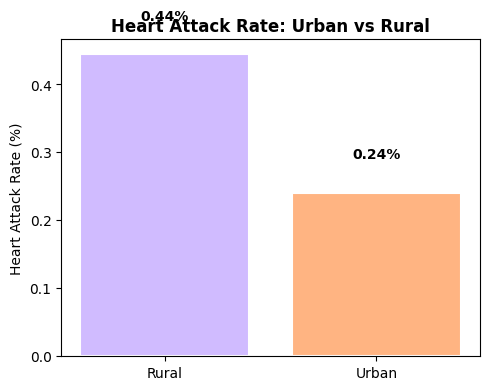

In [ ]:
print("[Plot 9] Urban vs Rural")
urb = df.groupby('Urban_Rural')[TARGET_COL].mean() * 100
urb.index = ['Rural' if i == 0 else 'Urban' for i in urb.index]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(urb.index, urb.values, color=[PALETTE[4], PALETTE[1]], edgecolor='white', linewidth=1.5)
for i, (idx, val) in enumerate(urb.items()):
    ax.text(i, val + 0.05, f"{val:.2f}%", ha='center', fontweight='bold')
ax.set_ylabel("Heart Attack Rate (%)")
ax.set_title("Heart Attack Rate: Urban vs Rural", fontweight='bold')
plt.tight_layout()
#save_fig("plot9_urban_rural")
plt.show()

[Plot 10] Stress & Depression


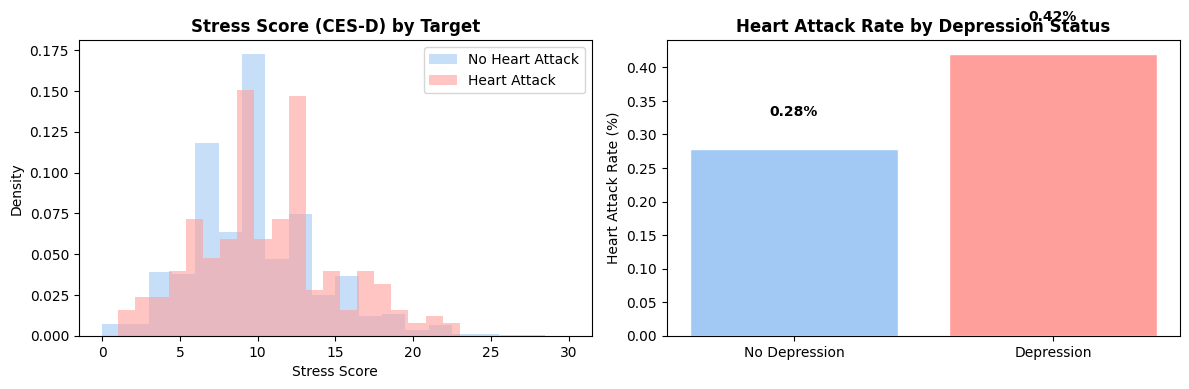

In [ ]:
print("[Plot 10] Stress & Depression")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, label, color in zip([0, 1], ['No Heart Attack', 'Heart Attack'],
                               [PALETTE[0], PALETTE[3]]):
    axes[0].hist(df[df[TARGET_COL] == val]['Stress_Score_CES_D'].dropna(),
                 bins=20, alpha=0.6, color=color, label=label, density=True)
axes[0].set_title("Stress Score (CES-D) by Target", fontweight='bold')
axes[0].set_xlabel("Stress Score")
axes[0].set_ylabel("Density")
axes[0].legend()

dep = df.groupby('Depression_Present')[TARGET_COL].mean() * 100
dep.index = ['No Depression', 'Depression']
axes[1].bar(dep.index, dep.values, color=[PALETTE[0], PALETTE[3]], edgecolor='white')
for i, (idx, val) in enumerate(dep.items()):
    axes[1].text(i, val + 0.05, f"{val:.2f}%", ha='center', fontweight='bold')
axes[1].set_ylabel("Heart Attack Rate (%)")
axes[1].set_title("Heart Attack Rate by Depression Status", fontweight='bold')
plt.tight_layout()
#save_fig("plot10_stress_depression")
plt.show()

In [ ]:
print("[Plot 11] Pairplot (key features)")
pair_cols = ['Age', 'Systolic_BP', 'BMI', 'Stress_Score_CES_D', TARGET_COL]
pair_df = df[pair_cols].dropna().sample(min(2000, len(df)), random_state=42)
pair_df[TARGET_COL] = pair_df[TARGET_COL].map({0: 'No HA', 1: 'Heart Attack'})

g = sns.pairplot(pair_df, hue=TARGET_COL, corner=True,
                 palette={'No HA': PALETTE[0], 'Heart Attack': PALETTE[3]},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde')
g.fig.suptitle("Pairplot: Key Clinical Features by Heart Attack Status",
               y=1.01, fontsize=13, fontweight='bold')
g.fig.savefig("plot11_pairplot.png", dpi=130, bbox_inches='tight')
plt.close()
plt.show()

[Plot 11] Pairplot (key features)


In [ ]:
print("\n" + "=" * 60)
print("STEP 5 — STATISTICAL TESTS (Point-Biserial / Chi-Square)")
print("=" * 60)

cont_cols = ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Pulse_Pressure',
             'Physical_Activity_Score', 'Annual_Income', 'Wealth_Total',
             'Stress_Score_CES_D', 'Education_Years']
print(f"\n{'Feature':<30} {'Corr':>8} {'p-value':>12} {'Significant':>12}")
print("-" * 64)
target_vals = df[TARGET_COL].values
for col in cont_cols:
    valid = df[[col, TARGET_COL]].dropna()
    r, p = stats.pointbiserialr(valid[TARGET_COL], valid[col])
    sig = "✓" if p < 0.05 else " "
    print(f"  {col:<28} {r:>8.4f} {p:>12.4e} {sig:>12}")

print("\nEDA complete. All plots saved as PNG files.")
print("Preprocessed dataset saved to: LASI_preprocessed.csv")
print("=" * 60)


STEP 5 — STATISTICAL TESTS (Point-Biserial / Chi-Square)

Feature                            Corr      p-value  Significant
----------------------------------------------------------------
  Age                            0.0240   7.9517e-11            ✓
  BMI                            0.0200   6.5406e-08            ✓
  Systolic_BP                    0.0003   9.4205e-01             
  Diastolic_BP                  -0.0088   1.7005e-02            ✓
  Pulse_Pressure                 0.0069   6.1833e-02             
  Physical_Activity_Score       -0.0179   1.3249e-06            ✓
  Annual_Income                  0.0035   3.4783e-01             
  Wealth_Total                   0.0047   2.0360e-01             
  Stress_Score_CES_D             0.0143   1.0625e-04            ✓
  Education_Years                0.0122   9.2370e-04            ✓

EDA complete. All plots saved as PNG files.
Preprocessed dataset saved to: LASI_preprocessed.csv


In [4]:
!pip install lightgbm shap

import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
df = pd.read_csv('/content/LASI_cleaned.csv')  # adjust path if needed

df.head()

,Patient_ID,Age,Gender,Female,Urban_Rural,State,Education_Level,Education_Years,BMI,BMI_Category,...,Heart_Attack_Ever,Health_Insurance_Gov,Living_Arrangement,Lives_Alone,Annual_Income,Wealth_Total,Wealth_Quintile,Stress_Score_CES_D,Stress_Score_CES_D_L,Depression_Present
0,101000100040101,70,1,0,1,1,0,0,16.406250,Underweight,...,0.0,0.0,2.0,0,24750.0,401600.0,2.0,13.0,5.0,1.0
1,101000100040102,68,2,1,1,1,0,0,26.314636,Overweight,...,0.0,0.0,2.0,0,24750.0,401600.0,2.0,12.0,4.0,1.0
2,101000100130101,54,1,0,1,1,5,12,23.335466,Overweight,...,0.0,0.0,4.0,0,87560.0,2139000.0,4.0,8.0,0.0,0.0
3,101000100130102,51,2,1,1,1,0,0,31.644283,Obese,...,0.0,0.0,4.0,0,87560.0,2139000.0,4.0,6.0,1.0,0.0
4,101000100130109,85,2,1,1,1,0,0,22.313276,Normal,...,0.0,0.0,5.0,0,87560.0,2139000.0,4.0,5.0,1.0,0.0


In [6]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Female', 'Urban_Rural', 'State',
       'Education_Level', 'Education_Years', 'BMI', 'BMI_Category',
       'Smoking_Current', 'Alcohol_Last3M', 'Physical_Activity_Score',
       'Physical_Activity_Active', 'Systolic_BP', 'Diastolic_BP',
       'Hypertension_Active', 'Diabetes_Active', 'Heart_Attack_2yr',
       'Heart_Attack_Ever', 'Health_Insurance_Gov', 'Living_Arrangement',
       'Lives_Alone', 'Annual_Income', 'Wealth_Total', 'Wealth_Quintile',
       'Stress_Score_CES_D', 'Stress_Score_CES_D_L', 'Depression_Present'],
      dtype='object')

In [8]:
# ============================================================
# LIGHTGBM + SHAP — CARDIOVASCULAR RISK PREDICTION (LASI)
# ============================================================

# ── Install dependencies
!pip install lightgbm shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve
)

# ============================================================
# STEP 1 — LOAD & PREPROCESS
# ============================================================
# Upload LASI_cleaned.csv to Colab first, then:
df = pd.read_csv("LASI_cleaned.csv")
print(f"Raw: {df.shape[0]:,} rows × {df.shape[1]} cols")

df.drop(columns=['Patient_ID'], inplace=True)

TARGET_COL = "Heart_Attack_Ever"
df.dropna(subset=[TARGET_COL], inplace=True)

df['BMI_Category_Enc'] = df['BMI_Category'].map(
    {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3}
)
df.drop(columns=['BMI_Category'], inplace=True)

# Imputation
MEDIAN_IMPUTE = ['BMI', 'Systolic_BP', 'Diastolic_BP', 'Physical_Activity_Score',
                 'Annual_Income', 'Wealth_Total', 'Stress_Score_CES_D', 'Stress_Score_CES_D_L']
MODE_IMPUTE   = ['Smoking_Current', 'Alcohol_Last3M', 'Health_Insurance_Gov',
                 'Living_Arrangement', 'Depression_Present', 'Heart_Attack_2yr', 'Wealth_Quintile']

for col in MEDIAN_IMPUTE:
    if col in df.columns: df[col] = df[col].fillna(df[col].median())
for col in MODE_IMPUTE:
    if col in df.columns: df[col] = df[col].fillna(df[col].mode()[0])
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().any(): df[col] = df[col].fillna(df[col].median())

# Outlier clipping (IQR × 3)
CLIP_COLS = ['BMI', 'Systolic_BP', 'Diastolic_BP', 'Physical_Activity_Score',
             'Annual_Income', 'Wealth_Total', 'Age']
for col in CLIP_COLS:
    if col not in df.columns: continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    df[col] = df[col].clip(Q1 - 3*(Q3-Q1), Q3 + 3*(Q3-Q1))

# Feature engineering
df['Pulse_Pressure']        = df['Systolic_BP'] - df['Diastolic_BP']
df['Hypertension_Diabetes'] = ((df['Hypertension_Active'] == 1) & (df['Diabetes_Active'] == 1)).astype(int)
df['Age_Group']             = pd.cut(df['Age'], bins=[0, 40, 55, 65, 80, 120],
                                      labels=[0, 1, 2, 3, 4]).astype(float)
df['SES_Risk']              = ((df['Wealth_Quintile'] <= 2).astype(int)
                               + (df['Education_Level'] <= 2).astype(int)
                               + (df['Health_Insurance_Gov'] == 0).astype(int))

X = df[[c for c in df.columns if c != TARGET_COL]]
y = df[TARGET_COL].astype(int)

print(f"Features: {X.shape[1]}")
print(f"Positives: {y.sum():,}  |  Negatives: {(y==0).sum():,}  |  Ratio: {(y==0).sum()/y.sum():.1f}:1")

# ============================================================
# STEP 2 — TRAIN/TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
pos   = y_train.sum()
neg   = (y_train == 0).sum()
scale = neg / pos
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}  |  scale_pos_weight: {scale:.1f}")

# ============================================================
# STEP 3 — LIGHTGBM TRAINING
# NOTE: Using native lgb.train with metric='auc' for early stopping.
# LGBMClassifier early-stops on binary_logloss which spikes at
# iteration 1 due to scale_pos_weight=52.7 — so we use the native API.
# ============================================================
dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_test,  label=y_test)

params = {
    'objective':         'binary',
    'metric':            'auc',
    'boosting':          'gbdt',
    'learning_rate':     0.05,
    'num_leaves':        63,
    'min_child_samples': 50,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'scale_pos_weight':  scale,
    'seed':              42,
    'verbose':           -1,
}

evals_result = {}
booster = lgb.train(
    params, dtrain,
    num_boost_round=600,
    valid_sets=[dval],
    valid_names=['valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.record_evaluation(evals_result),
        lgb.log_evaluation(period=100),
    ]
)

print(f"\nBest iteration : {booster.best_iteration}")
print(f"Best valid AUC : {max(evals_result['valid']['auc']):.4f}")

# ============================================================
# STEP 4 — EVALUATION + OPTIMAL THRESHOLD
# ============================================================
y_pred_prob = booster.predict(X_test, num_iteration=booster.best_iteration)
roc_auc     = roc_auc_score(y_test, y_pred_prob)
pr_auc      = average_precision_score(y_test, y_pred_prob)

# Find threshold that maximises F1 on positive class
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_pred_prob)
f1_arr      = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
best_thresh = thresh_arr[np.argmax(f1_arr)]
y_pred      = (y_pred_prob >= best_thresh).astype(int)

print(f"\nROC-AUC          : {roc_auc:.4f}")
print(f"PR-AUC           : {pr_auc:.4f}")
print(f"Optimal threshold: {best_thresh:.4f}  (max F1 = {np.max(f1_arr):.4f})")
print("\nClassification Report (optimal threshold):")
print(classification_report(y_test, y_pred, target_names=['No HA', 'Heart Attack']))

# ============================================================
# STEP 5 — EVALUATION PLOTS
# ============================================================
fig = plt.figure(figsize=(20, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── ROC Curve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax1.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
ax1.plot([0,1], [0,1], 'k--', lw=1)
ax1.fill_between(fpr, tpr, alpha=0.1)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', fontweight='bold')
ax1.legend()

# ── Precision-Recall Curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(rec_arr, prec_arr, lw=2, label=f'PR-AUC = {pr_auc:.4f}')
ax2.axhline(y_test.mean(), color='gray', lw=1, linestyle='--',
            label=f'Baseline = {y_test.mean():.4f}')
ax2.fill_between(rec_arr, prec_arr, alpha=0.1)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.legend()

# ── Confusion Matrix
ax3 = fig.add_subplot(gs[0, 2])
cm  = confusion_matrix(y_test, y_pred)
im  = ax3.imshow(cm, cmap='Blues', aspect='auto')
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax3.text(j, i, f'{labels[i][j]}\n{cm[i,j]:,}',
                 ha='center', va='center', fontsize=12, fontweight='bold')
ax3.set_xticks([0, 1]); ax3.set_yticks([0, 1])
ax3.set_xticklabels(['Pred No HA', 'Pred HA'])
ax3.set_yticklabels(['Act No HA', 'Act HA'])
ax3.set_title(f'Confusion Matrix\n(thresh={best_thresh:.3f})', fontweight='bold')
plt.colorbar(im, ax=ax3)

# ── Score Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(y_pred_prob[y_test == 0], bins=60, alpha=0.6, density=True, label='No HA')
ax4.hist(y_pred_prob[y_test == 1], bins=60, alpha=0.7, density=True, label='Heart Attack')
ax4.axvline(best_thresh, color='red', lw=1.5, linestyle='--', label=f'Threshold={best_thresh:.3f}')
ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Density')
ax4.set_title('Score Distribution by Class', fontweight='bold')
ax4.legend()

# ── F1 vs Threshold
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(thresh_arr, f1_arr, lw=2)
ax5.axvline(best_thresh, color='red', lw=1.5, linestyle='--',
            label=f'Best thresh = {best_thresh:.3f}')
ax5.set_xlabel('Threshold')
ax5.set_ylabel('F1 Score (Positive class)')
ax5.set_title('F1 Score vs Decision Threshold', fontweight='bold')
ax5.legend()

# ── Feature Importance (Gain)
ax6 = fig.add_subplot(gs[1, 2])
importance = pd.Series(
    booster.feature_importance(importance_type='gain'), index=X.columns
).nlargest(20).sort_values()
ax6.barh(importance.index, importance.values, height=0.7)
ax6.set_xlabel('Importance (gain)')
ax6.set_title('Top-20 Feature Importance (Gain)', fontweight='bold')

fig.suptitle('LightGBM — Cardiovascular Risk Prediction | LASI Dataset',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("lgbm_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STEP 6 — SHAP ANALYSIS
# ============================================================
sample_size = min(3000, len(X_test))
X_shap      = X_test.sample(sample_size, random_state=42)

explainer   = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_shap)
sv          = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"SHAP matrix: {sv.shape}")

mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=X_shap.columns)

# ── Plot 1: Beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_shap, show=True)

# ── Plot 2: Mean |SHAP| Bar
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, plot_type='bar', show=True)

# ── Plot 3: Dependence plots for top-4 features
top4 = mean_shap.nlargest(4).index.tolist()
fig3, axes3 = plt.subplots(1, 4, figsize=(20, 5))
for ax_i, feat in zip(axes3, top4):
    shap.dependence_plot(feat, sv, X_shap, ax=ax_i, show=False, dot_size=6, alpha=0.4)
    ax_i.set_title(feat, fontweight='bold')
fig3.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 4: Waterfall for highest-risk patient
hr_idx   = np.argmax(y_pred_prob)
X_single = pd.DataFrame(X_test.iloc[[hr_idx]])
sv_exp   = explainer(X_single)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(sv_exp[0], max_display=15, show=True)

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"ROC-AUC          : {roc_auc:.4f}")
print(f"PR-AUC           : {pr_auc:.4f}")
print(f"Best F1 (HA)     : {np.max(f1_arr):.4f}  @ threshold {best_thresh:.4f}")
print(f"Best iteration   : {booster.best_iteration}")
print(f"\nTop-5 SHAP features:")
for feat, val in mean_shap.nlargest(5).items():
    print(f"  {feat:<35} {val:.4f}")

Raw: 73,408 rows × 29 cols
Features: 31
Positives: 1,364  |  Negatives: 71,847  |  Ratio: 52.7:1

Train: 58,568  |  Test: 14,643  |  scale_pos_weight: 52.7
Training until validation scores don't improve for 50 rounds
[100]	valid's auc: 0.836548
Early stopping, best iteration is:
[55]	valid's auc: 0.837948

Best iteration : 55
Best valid AUC : 0.8379

ROC-AUC          : 0.8379
PR-AUC           : 0.2668
Optimal threshold: 0.7609  (max F1 = 0.2925)

Classification Report (optimal threshold):
              precision    recall  f1-score   support

       No HA       0.99      0.99      0.99     14370
Heart Attack       0.35      0.25      0.29       273

    accuracy                           0.98     14643
   macro avg       0.67      0.62      0.64     14643
weighted avg       0.97      0.98      0.98     14643

SHAP matrix: (3000, 31)

FINAL SUMMARY
ROC-AUC          : 0.8379
PR-AUC           : 0.2668
Best F1 (HA)     : 0.2925  @ threshold 0.7609
Best iteration   : 55

Top-5 SHAP features